### 📈 **Darts: A Modern Time Series Forecasting Library**

Darts is a Python library designed to make time series forecasting and anomaly detection intuitive and powerful. It supports a wide range of models—from classical statistical approaches like ARIMA to cutting-edge deep learning architectures.

🔧 Key Features
- Unified API: All models use fit() and predict() methods, similar to scikit-learn.
- Model Variety: Includes ARIMA, Prophet, RNNs, Transformers, and more.
- Multivariate Support: Handles both univariate and multivariate time series.
- Probabilistic Forecasting: Offers uncertainty estimates for predictions.
- Backtesting & Ensembling: Easily evaluate and combine models.
- External Data Integration: Incorporate covariates and exogenous variables.

🧠 Use Cases
- Demand forecasting
- Predictive maintenance
- Financial time series analysis
- Energy consumption modeling

In [1]:
# ! pip install darts

# Import Other Packages and Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf, month_plot, quarter_plot
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing, Holt
from sklearn.metrics import root_mean_squared_error, mean_squared_error, mean_absolute_error
from darts.timeseries import TimeSeries
from darts.utils.timeseries_generation import datetime_attribute_timeseries
from darts.dataprocessing.transformers import Scaler
from darts.models import RNNModel
import warnings
warnings.filterwarnings('ignore')

Read in dataset as a numpy array.

In [3]:
df = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/Time Series Analysis/Python - Time Series Forecasting/Deep Learning for Time Series Forecasting /LSTM/Hourly-train.csv',
                 header=None).values.squeeze()
df

array([['V1', 'V2', 'V3', ..., 'V959', 'V960', 'V961'],
       ['H1', '605', '586', ..., nan, nan, nan],
       ['H2', '3124', '2990', ..., nan, nan, nan],
       ...,
       ['H412', '19', '30', ..., '73', '39', '36'],
       ['H413', '21', '16', ..., '53', '38', '46'],
       ['H414', '15', '13', ..., '35', '26', '17']], dtype=object)

In [4]:
# Remove the first row and first column, convert remaining values to floats, and transpose.
df = df[1:,1:].astype(float).T
df

array([[ 605., 3124., 1828., ...,   19.,   21.,   15.],
       [ 586., 2990., 1806., ...,   30.,   16.,   13.],
       [ 586., 2862., 1897., ...,   12.,   17.,   13.],
       ...,
       [  nan,   nan,   nan, ...,   73.,   53.,   35.],
       [  nan,   nan,   nan, ...,   39.,   38.,   26.],
       [  nan,   nan,   nan, ...,   36.,   46.,   17.]])

In [5]:
# Identify and remove any rows that contain 'NaN' values.
nan_rows = np.isnan(df).any(axis=1)
df = df[~nan_rows]
df

array([[ 605., 3124., 1828., ...,   19.,   21.,   15.],
       [ 586., 2990., 1806., ...,   30.,   16.,   13.],
       [ 586., 2862., 1897., ...,   12.,   17.,   13.],
       ...,
       [ 752., 3460., 1581., ...,   18.,   17.,   13.],
       [ 739., 3248., 1570., ...,   13.,   16.,   17.],
       [ 684., 3105., 1518., ...,   17.,   15.,   21.]])

In [6]:
len(df)

700

In [7]:
# Convert to pandas dataframe
df = pd.DataFrame(df)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,404,405,406,407,408,409,410,411,412,413
0,605.0,3124.0,1828.0,6454.0,4263.0,5780.0,52817.0,32479.0,39455.0,513.0,...,68.0,21.0,214.0,19.0,31.0,153.0,24.0,19.0,21.0,15.0
1,586.0,2990.0,1806.0,6324.0,4297.0,5497.0,51773.0,31018.0,38279.0,512.0,...,48.0,15.0,238.0,31.0,39.0,196.0,30.0,30.0,16.0,13.0
2,586.0,2862.0,1897.0,6075.0,4236.0,5306.0,50907.0,30033.0,36944.0,506.0,...,33.0,15.0,130.0,25.0,22.0,163.0,22.0,12.0,17.0,13.0
3,559.0,2809.0,1750.0,5949.0,4080.0,5178.0,50224.0,27716.0,35984.0,500.0,...,21.0,17.0,69.0,23.0,17.0,131.0,14.0,16.0,19.0,16.0
4,511.0,2544.0,1679.0,5858.0,3883.0,5235.0,49496.0,25067.0,33721.0,490.0,...,30.0,15.0,68.0,14.0,13.0,82.0,19.0,13.0,16.0,26.0


Because we don't have any time information, we will insert dummy time information.

In [8]:
start_date = pd.to_datetime('2000-01-01 00:00:00')
series = TimeSeries.from_times_and_values(pd.date_range(
                                          start=start_date,
                                          periods = len(df),
                                          freq='H'),
                                          df.values
                                          )


In [9]:
df_with_time = series.to_dataframe()
df_with_time.head()

,0,1,2,3,4,5,6,7,8,9,...,404,405,406,407,408,409,410,411,412,413
2000-01-01 00:00:00,605.0,3124.0,1828.0,6454.0,4263.0,5780.0,52817.0,32479.0,39455.0,513.0,...,68.0,21.0,214.0,19.0,31.0,153.0,24.0,19.0,21.0,15.0
2000-01-01 01:00:00,586.0,2990.0,1806.0,6324.0,4297.0,5497.0,51773.0,31018.0,38279.0,512.0,...,48.0,15.0,238.0,31.0,39.0,196.0,30.0,30.0,16.0,13.0
2000-01-01 02:00:00,586.0,2862.0,1897.0,6075.0,4236.0,5306.0,50907.0,30033.0,36944.0,506.0,...,33.0,15.0,130.0,25.0,22.0,163.0,22.0,12.0,17.0,13.0
2000-01-01 03:00:00,559.0,2809.0,1750.0,5949.0,4080.0,5178.0,50224.0,27716.0,35984.0,500.0,...,21.0,17.0,69.0,23.0,17.0,131.0,14.0,16.0,19.0,16.0
2000-01-01 04:00:00,511.0,2544.0,1679.0,5858.0,3883.0,5235.0,49496.0,25067.0,33721.0,490.0,...,30.0,15.0,68.0,14.0,13.0,82.0,19.0,13.0,16.0,26.0


# EDA

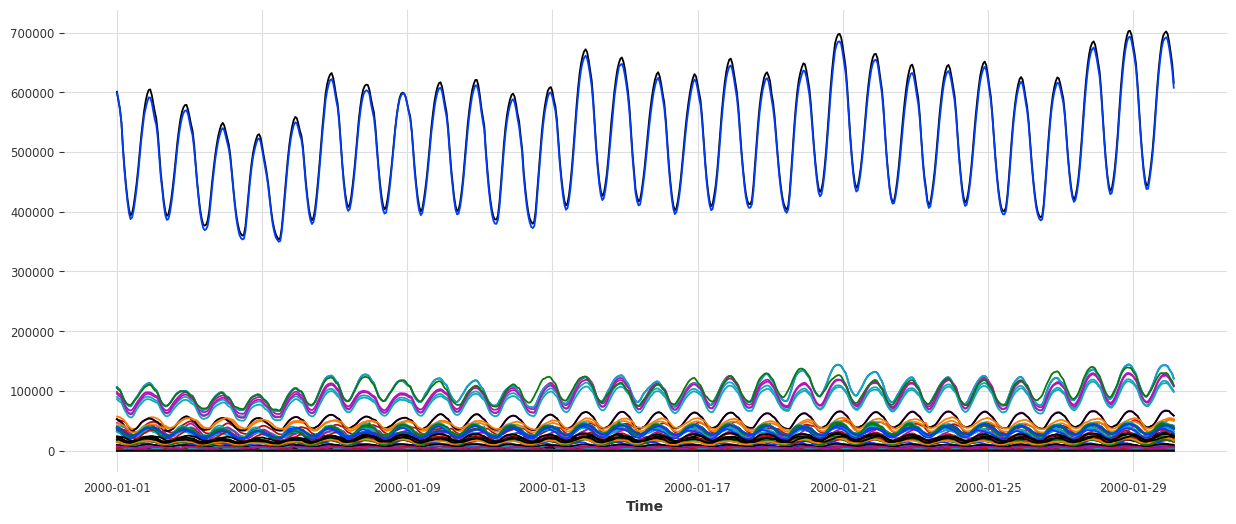

In [10]:
# Plot the multiple time-series

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(df_with_time.index, df.values)
plt.xlabel('Time')
plt.show()

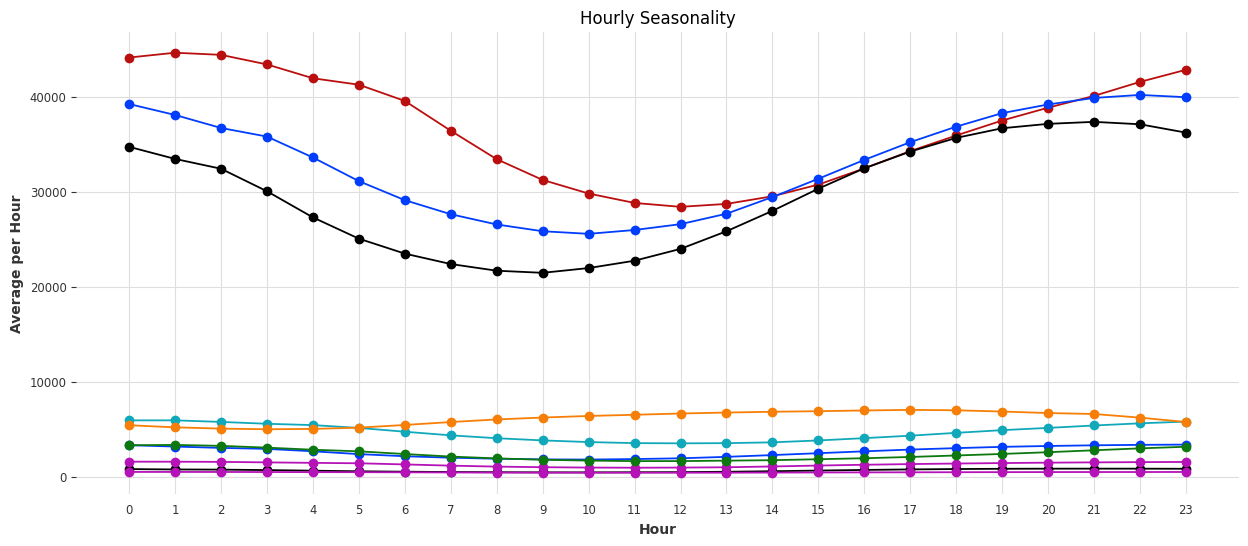

In [11]:
# Hourly Seasonality - plot the first 10 time series

fig, ax = plt.subplots(figsize=(15, 6))
hourly_means = df_with_time.groupby(df_with_time.index.hour).mean()
plt.plot(hourly_means.iloc[:,:10],marker = 'o')
plt.xlabel('Hour')
plt.ylabel('Average per Hour')
plt.title('Hourly Seasonality')
plt.xticks(range(24))
plt.show()

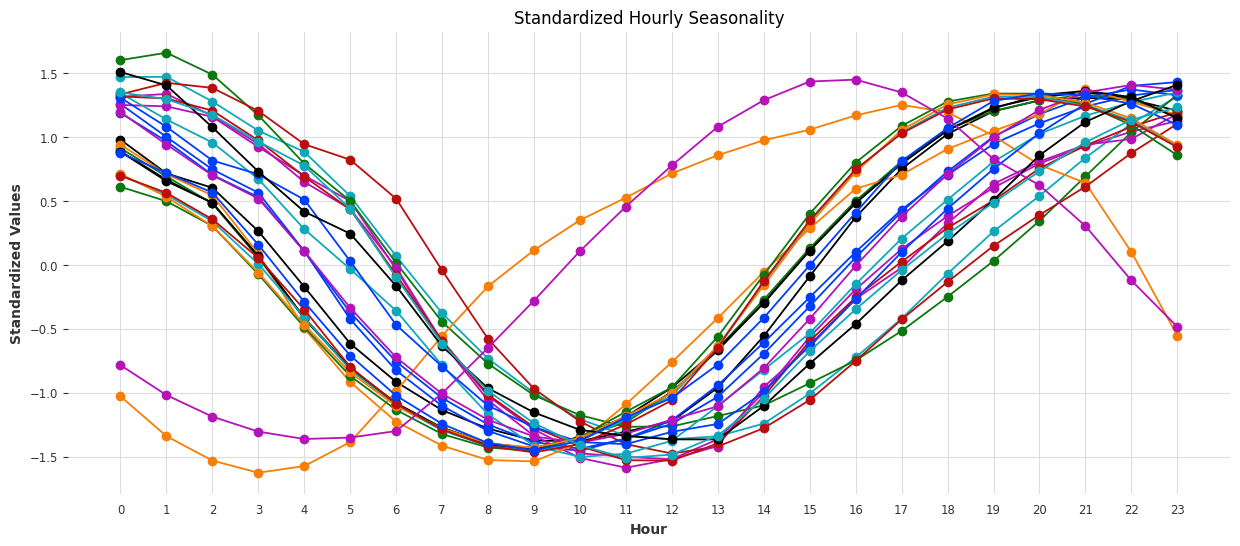

In [12]:
# Standardizing the hourly means

hourly_means_std = (hourly_means - np.mean(hourly_means,axis=0)) / np.std(hourly_means,axis=0)

fig, ax = plt.subplots(figsize=(15, 6))
plt.plot(hourly_means_std.iloc[:,:25],marker = 'o')
plt.xlabel('Hour')
plt.ylabel('Standardized Values')
plt.title('Standardized Hourly Seasonality')
plt.xticks(range(24))
plt.show()


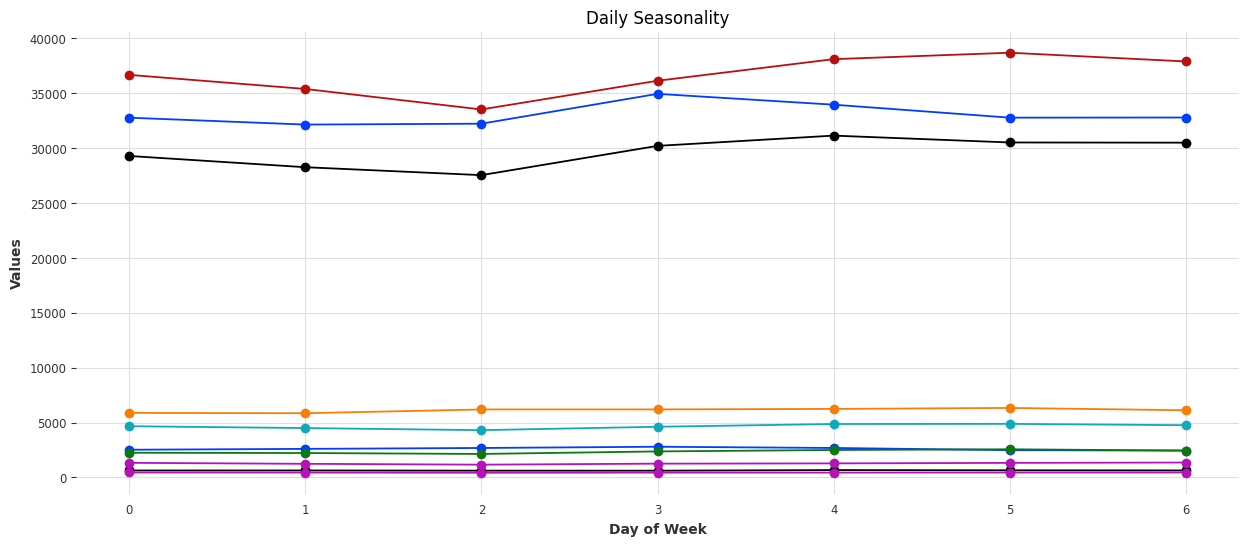

In [13]:
# Weekly Seasonality

# Daily Seasonality Plot

daily_means = df_with_time.groupby(df_with_time.index.dayofweek).mean()

fig, ax = plt.subplots(figsize=(15, 6))
plt.plot(daily_means.iloc[:,:10],marker = 'o')
plt.xlabel('Day of Week')
plt.ylabel('Values')
plt.title('Daily Seasonality')
plt.xticks(range(7))
plt.show()

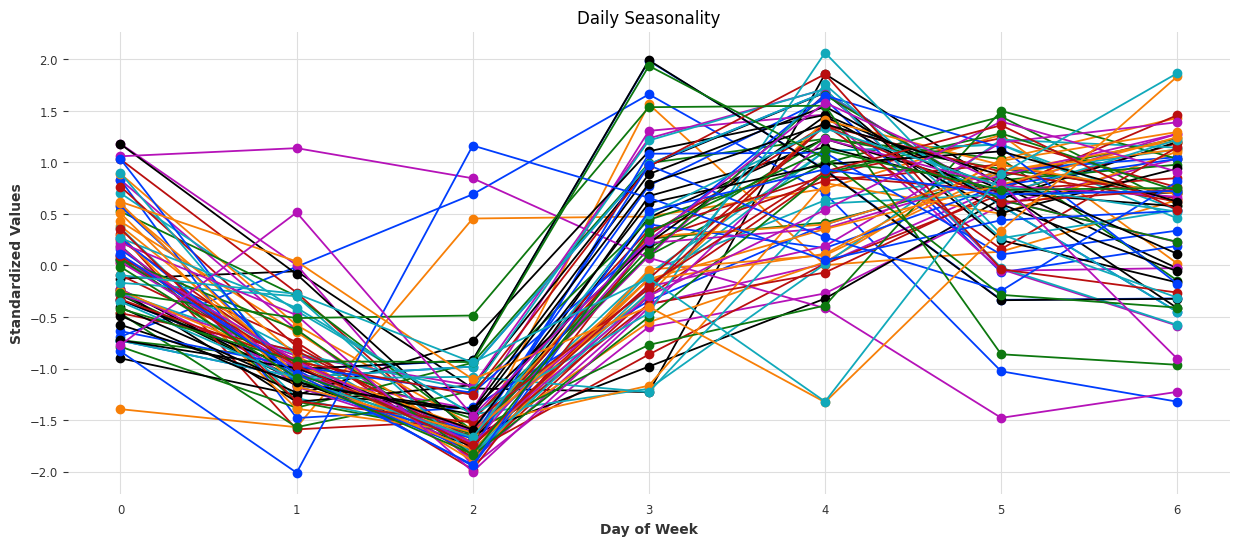

In [14]:
daily_means_std = (daily_means - np.mean(daily_means,axis=0)) / np.std(daily_means,axis=0)

fig, ax = plt.subplots(figsize=(15, 6))
plt.plot(daily_means_std.iloc[:,:75],marker = 'o')
plt.xlabel('Day of Week')
plt.ylabel('Standardized Values')
plt.title('Daily Seasonality')
plt.xticks(range(7))
plt.show()

# Prepare for LSTM

In [15]:
# Build the covariate series

# Hourly

hourly_series = datetime_attribute_timeseries(
                  series,
                  attribute = 'hour',
                  one_hot = True
                  )

# Daily

weekday_series = datetime_attribute_timeseries(
                  hourly_series,
                  attribute = 'dayofweek',
                  one_hot = True
                  )

In [16]:
# Instantiate a Scaler function and apply to the multiple series

scaler = Scaler()
scaled_series = scaler.fit_transform(series)

In [17]:
# Stack the covariates

one_hot_covariates = weekday_series.stack(hourly_series)
one_hot_covariates

<TimeSeries (time: 700, component: 31, sample: 1)> Size: 174kB
array([[[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]],

       [[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]],

       [[0.],
        [0.],
        [0.],
        ...,
...
        ...,
        [0.],
        [0.],
        [0.]],

       [[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]],

       [[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]]])
Coordinates:
  * time       (time) datetime64[ns] 6kB 2000-01-01 ... 2000-01-30T03:00:00
  * component  (component) object 248B 'dayofweek_0' 'dayofweek_1' ... 'hour_23'
Dimensions without coordinates: sample
Attributes:
    static_covariates:  None
    hierarchy:          None
    metadata:           None

#LSTM

- `training_length` = `input_chunk_length` + `forecast_horizon`   
- `input_chunk_length` > `forecast_horizon`

In [18]:
# Define input and output parameters

input_chunk_length = 72
forecasting_horizon = 48
training_length = input_chunk_length + forecasting_horizon

In [19]:
# Define the LSTM model

rnn = RNNModel(
    model = 'LSTM',
    hidden_dim = 20,
    n_rnn_layers = 2,
    dropout = 0.1,
    n_epochs = 10,
    optimizer_kwargs = {'lr': 3e-3},
    model_name = 'lstm_model',
    random_state = 42,
    training_length = training_length,
    input_chunk_length = input_chunk_length,
    pl_trainer_kwargs = {"accelerator": "gpu", "devices": [0]},
    save_checkpoints = True,
    force_reset = True
    )

In [20]:
# Fit the model

rnn.fit(scaled_series,
        future_covariates=one_hot_covariates,
        verbose = True
        )

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 40.7 K | train
6 | V               | Linear           | 8.7 K  | train
-------------------------------------------------------------
49.4 K    Trainable params
0         Non-trainable p

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


RNNModel(model=LSTM, hidden_dim=20, n_rnn_layers=2, dropout=0.1, training_length=120, n_epochs=10, optimizer_kwargs={'lr': 0.003}, model_name=lstm_model, random_state=42, input_chunk_length=72, pl_trainer_kwargs={'accelerator': 'gpu', 'devices': [0]}, save_checkpoints=True, force_reset=True)

In [21]:
# Cross Validation with Rolling Forecast Window

cv = rnn.historical_forecasts(series = scaled_series,
                              future_covariates = one_hot_covariates,
                              start = df.shape[0] - 200,  # arbitrarily chosen
                              forecast_horizon = forecasting_horizon,
                              retrain = True,
                              stride = 24,   # since we're forecasting 48 hours out
                              last_points_only = False
                              )

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 40.7 K | train
6 | V               | Linear           | 8.7 K  | train
-------------------------------------------------------------
49.4 K    Trainable params
0         Non-trainable p

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss  

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss  

...

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss  

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss  

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


In [22]:
# CV Results

cv

[<TimeSeries (time: 48, component: 414, sample: 1)> Size: 159kB
 array([[[0.86070699],
         [0.70880164],
         [0.68491215],
         ...,
         [0.16653216],
         [0.34613128],
         [0.11401878]],
 
        [[0.86815317],
         [0.73162628],
         [0.72704483],
         ...,
         [0.13145383],
         [0.28542813],
         [0.0822854 ]],
 
        [[0.8593913 ],
         [0.73633414],
         [0.75133413],
         ...,
 ...
         ...,
         [0.34754762],
         [0.44338914],
         [0.21652486]],
 
        [[0.74463343],
         [0.58480826],
         [0.51250118],
         ...,
         [0.2877312 ],
         [0.42983257],
         [0.18646031]],
 
        [[0.80800849],
         [0.65600237],
         [0.6152383 ],
         ...,
         [0.21822038],
         [0.38882538],
         [0.14846823]]])
 Coordinates:
   * time       (time) datetime64[ns] 384B 2000-01-21T20:00:00 ... 2000-01-23T...
   * component  (component) object 3kB '0' '1' 

In [23]:
# Initialize a list to store RMSE values for cross-validation
rmse_cv = []

# Iterate over each forecast result from cross-validation
for i in range(len(cv)):

  # Convert the forecasted values back to the original scale
  predictions = TimeSeries.to_dataframe(scaler.inverse_transform(cv[i]))
  # Convert original time series to DataFrame
  series_pandas = TimeSeries.to_dataframe(series)

  # Determine the range of dates for actual values
  start = predictions.index.min()
  end = predictions.index.max()
  # Extract the actual values from the original dataset
  actuals = series_pandas[start:end]

  # Calculate the RMSE for the current cross-validation fold
  error_cv = np.sqrt(mean_squared_error(actuals, predictions))
  # Append the RMSE to the list
  rmse_cv.append(error_cv)

# Print the mean RMSE across all cross-validation folds
print(np.mean(rmse_cv))

2247.1342143786155


# Visualize the Predictions (4 examples)

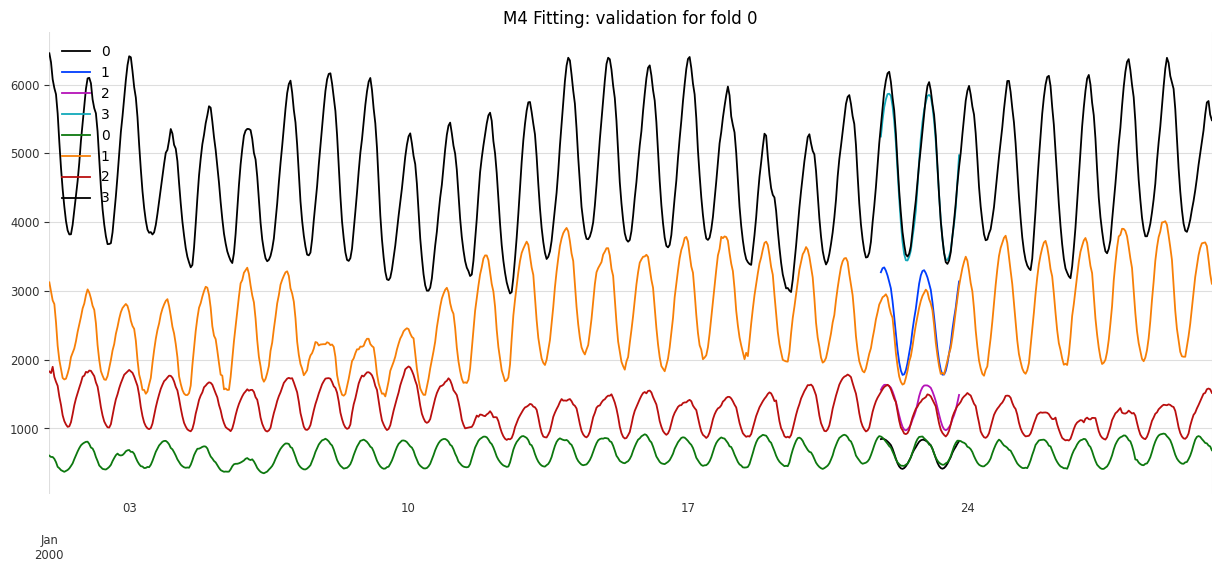

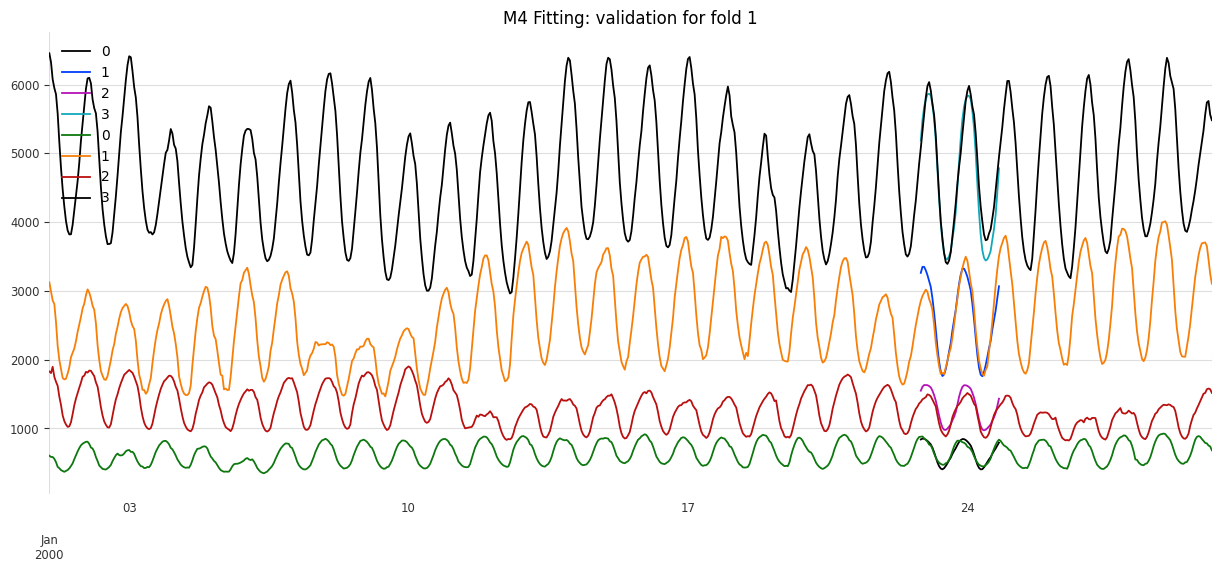

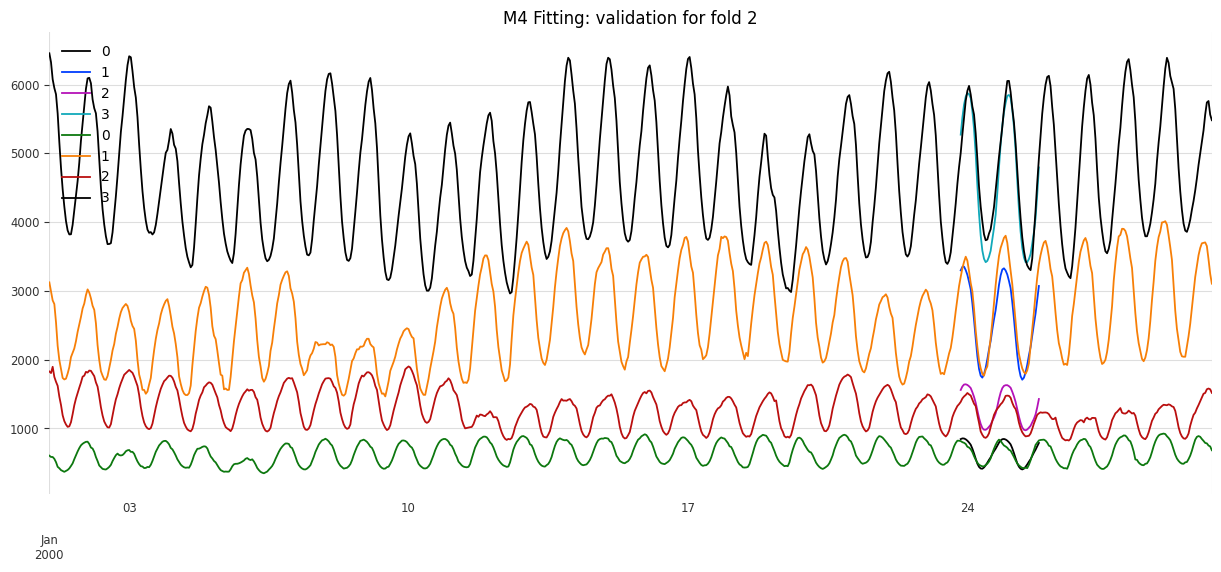

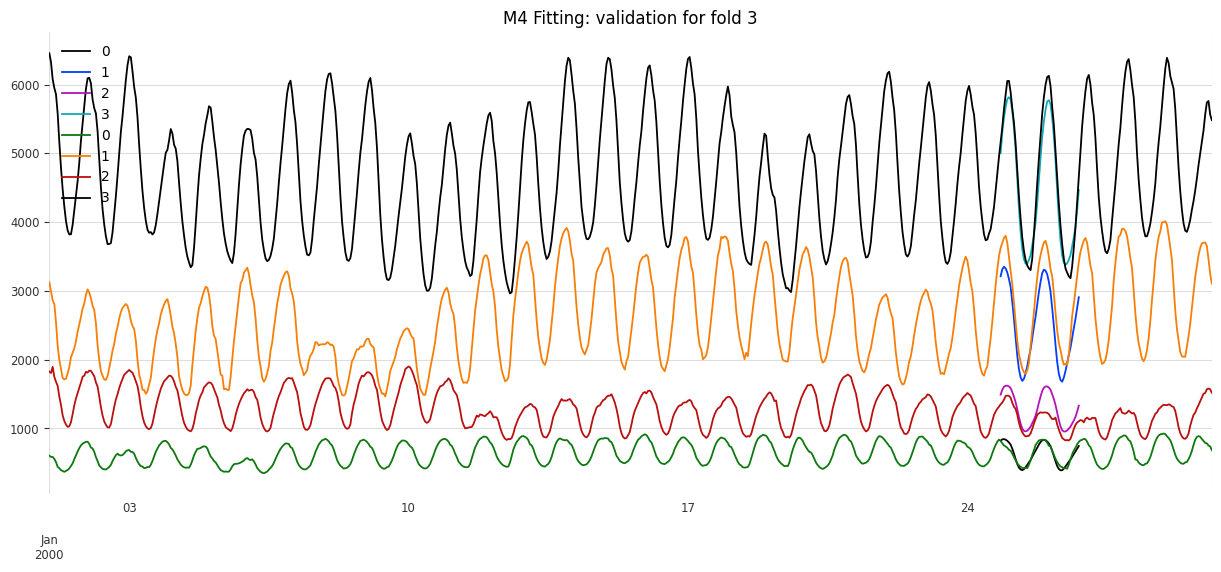

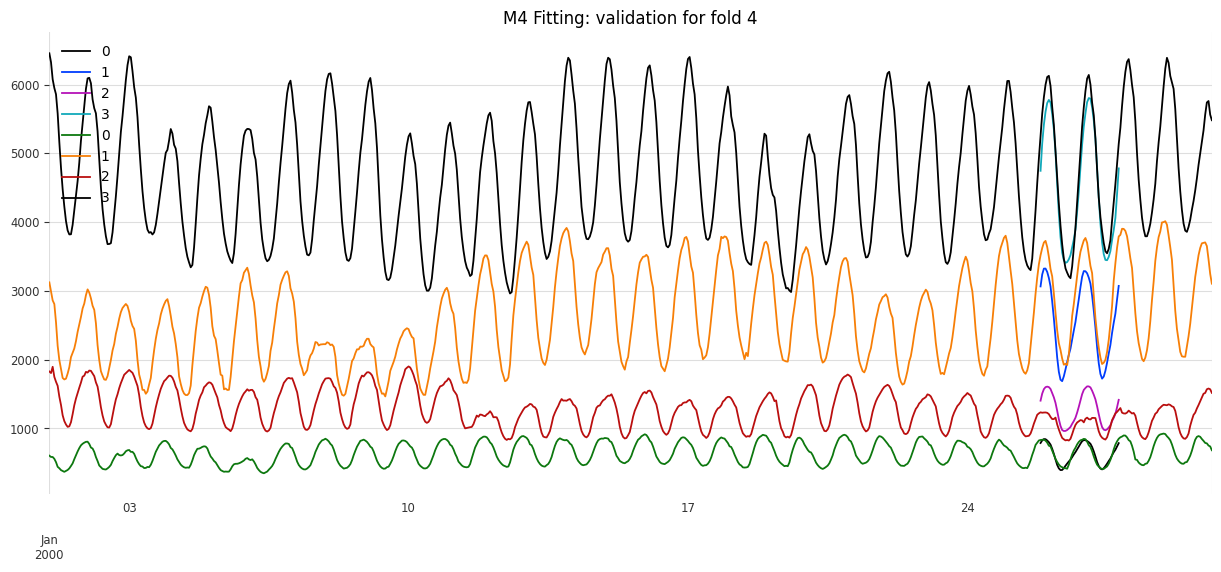

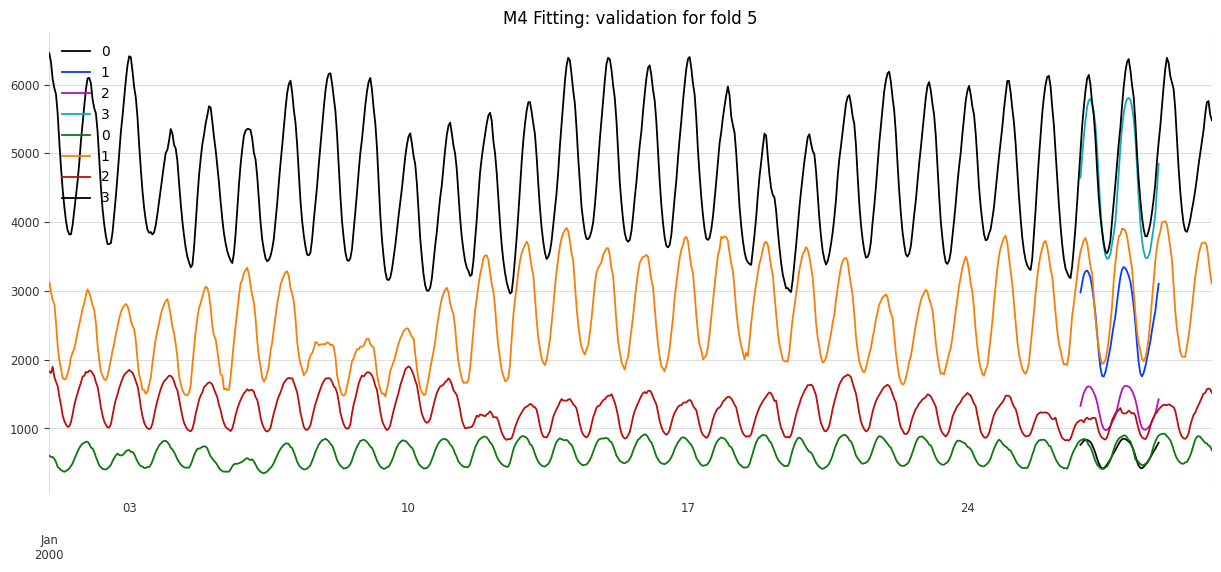

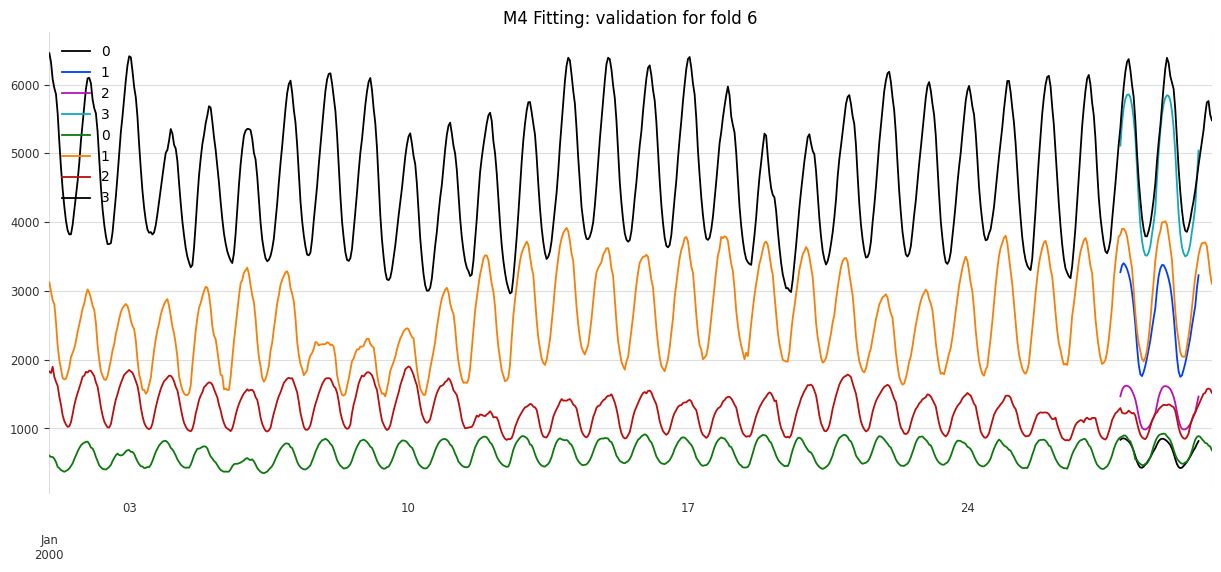

In [24]:
for i in range(len(cv)):
  plt.figure(figsize=(15, 6))
  # Convert to pandas DataFrame before plotting and plot a subset
  predictions_df = scaler.inverse_transform(cv[i]).to_dataframe()
  predictions_df.iloc[:, :4].plot(label = 'Predictions',ax=plt.gca())

  # Convert to pandas DataFrame before plotting and plot a subset
  series_df = series.to_dataframe()
  series_df.iloc[:, :4].plot(label = 'Actuals', ax=plt.gca())

  plt.title(f"M4 Fitting: validation for fold {i}")
  plt.legend()
  plt.show()

# Hyperparameter Tuning

In [28]:
# Set up the parameter grid

param_grid = {'n_rnn_layers': [2, 4],
              'hidden_dim': [10, 20],
              'dropout': [0.1, 0.2],
              'n_epochs': [10, 20],
              'lr': [3e-3],
              'training_length': [input_chunk_length + forecasting_horizon],
              'input_chunk_length': [input_chunk_length]
              }


In [29]:
# Generate all combinations of parameters

from sklearn.model_selection import ParameterGrid

all_params = list(ParameterGrid(param_grid))
len(all_params)
all_params

[{'dropout': 0.1,
  'hidden_dim': 10,
  'input_chunk_length': 72,
  'lr': 0.003,
  'n_epochs': 10,
  'n_rnn_layers': 2,
  'training_length': 120},
 {'dropout': 0.1,
  'hidden_dim': 10,
  'input_chunk_length': 72,
  'lr': 0.003,
  'n_epochs': 10,
  'n_rnn_layers': 4,
  'training_length': 120},
 {'dropout': 0.1,
  'hidden_dim': 10,
  'input_chunk_length': 72,
  'lr': 0.003,
  'n_epochs': 20,
  'n_rnn_layers': 2,
  'training_length': 120},
 {'dropout': 0.1,
  'hidden_dim': 10,
  'input_chunk_length': 72,
  'lr': 0.003,
  'n_epochs': 20,
  'n_rnn_layers': 4,
  'training_length': 120},
 {'dropout': 0.1,
  'hidden_dim': 20,
  'input_chunk_length': 72,
  'lr': 0.003,
  'n_epochs': 10,
  'n_rnn_layers': 2,
  'training_length': 120},
 {'dropout': 0.1,
  'hidden_dim': 20,
  'input_chunk_length': 72,
  'lr': 0.003,
  'n_epochs': 10,
  'n_rnn_layers': 4,
  'training_length': 120},
 {'dropout': 0.1,
  'hidden_dim': 20,
  'input_chunk_length': 72,
  'lr': 0.003,
  'n_epochs': 20,
  'n_rnn_layers': 2

In [34]:
# Initialize a list to store RMSE values for each parameter combination

rmse = []

for params in all_params:

  # Build the model

  rnn = RNNModel(
      model = 'LSTM',
      hidden_dim = params['hidden_dim'],
      n_rnn_layers = params['n_rnn_layers'],
      dropout = params['dropout'],
      n_epochs = params['n_epochs'],
      optimizer_kwargs = {'lr': params['lr']},
      model_name = 'lstm_model',
      random_state = 42,
      training_length = params['training_length'],
      input_chunk_length = params['input_chunk_length'],
      pl_trainer_kwargs = {'accelerator': 'gpu', 'devices': [0]},
      save_checkpoints = True,
      force_reset = True
      )

  # Fit the model

  rnn.fit(scaled_series,
          future_covariates=one_hot_covariates,
          verbose = True
          )

  # Cross Validation with Rolling Forecast Window

  cv = rnn.historical_forecasts(series = scaled_series,
                              future_covariates = one_hot_covariates,
                              start = df.shape[0] - 200,
                              forecast_horizon = forecasting_horizon,
                              retrain = True,
                              stride = 24,
                              last_points_only = False
                              )

  # Initialize a list to store RMSE values for cross-validation
  rmse_cv = []

  # Iterate over each forecast result from cross-validation
  for i in range(len(cv)):

    # Convert forecasted values back to the original scale
    predictions = TimeSeries.to_dataframe(scaler.inverse_transform(cv[i]))
    # Convert original time series to DataFrame
    series_pandas = TimeSeries.to_dataframe(series)

    # Determine the range of dates for actual values
    start = predictions.index.min()
    end = predictions.index.max()

    # Extract the actual values from the original dataset
    actuals = series_pandas[start:end]

    # Calculate the RMSE for the current cross-validation fold
    error_cv = np.sqrt(mean_squared_error(actuals, predictions))
    # Append the RMSE to the list
    rmse_cv.append(error_cv)

  # Calculate and store the mean RMSE for the current parameter combination
  error = np.mean(rmse_cv)
  rmse.append(error)


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 19.2 K | train
6 | V               | Linear           | 4.6 K  | train
-------------------------------------------------------------
23.7 K    Trainable params
0         Non-trainable p

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 19.2 K | train
6 | V               | Linear           | 4.6 K  | train
-----------------------

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss  

...

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss  

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss  

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


In [37]:
rmse

[np.float64(5292.885998187815),
 np.float64(7017.301667958136),
 np.float64(2619.8035549591127),
 np.float64(5259.150358245502),
 np.float64(2247.1342143786155),
 np.float64(4501.62755301864),
 np.float64(2417.1007549134106),
 np.float64(2531.7343389495727),
 np.float64(5322.145001848466),
 np.float64(6911.357469518464),
 np.float64(2671.852536008642),
 np.float64(5308.380080254494),
 np.float64(2365.045877466256),
 np.float64(5095.174407104788),
 np.float64(2390.3852449076103),
 np.float64(2549.396090556819)]

In [38]:
grid = ParameterGrid(param_grid)
tuning_results = pd.DataFrame(grid)
tuning_results['rmse'] = rmse
tuning_results

,dropout,hidden_dim,input_chunk_length,lr,n_epochs,n_rnn_layers,training_length,rmse
0,0.1,10,72,0.003,10,2,120,5292.885998
1,0.1,10,72,0.003,10,4,120,7017.301668
2,0.1,10,72,0.003,20,2,120,2619.803555
3,0.1,10,72,0.003,20,4,120,5259.150358
4,0.1,20,72,0.003,10,2,120,2247.134214
5,0.1,20,72,0.003,10,4,120,4501.627553
6,0.1,20,72,0.003,20,2,120,2417.100755
7,0.1,20,72,0.003,20,4,120,2531.734339
8,0.2,10,72,0.003,10,2,120,5322.145002
9,0.2,10,72,0.003,10,4,120,6911.357470


In [39]:
# Get the best parameters

best_params = tuning_results.loc[tuning_results['rmse'] == tuning_results['rmse'].min()]
best_params


,dropout,hidden_dim,input_chunk_length,lr,n_epochs,n_rnn_layers,training_length,rmse
4,0.1,20,72,0.003,10,2,120,2247.134214


In [40]:

best_params = best_params.drop('rmse', axis=1)
best_params.to_csv('best_params.csv')

In [41]:
best_params

,dropout,hidden_dim,input_chunk_length,lr,n_epochs,n_rnn_layers,training_length
4,0.1,20,72,0.003,10,2,120


In [44]:
# Fetch the best parameters

best_params = pd.read_csv('best_params.csv', index_col=0)
best_params
#

,dropout,hidden_dim,input_chunk_length,lr,n_epochs,n_rnn_layers,training_length
4,0.1,20,72,0.003,10,2,120


In [ ]:
# Fetch the hyperparameters of the best model run

n_rnn_layers = best_params['n_rnn_layers'].item()
hidden_dim = best_params['hidden_dim'].item()
dropout = best_params['dropout'].item()
n_epochs = best_params['n_epochs'].item()
lr = best_params['lr'].item()
training_length = best_params['training_length'].item()
input_chunk_length = best_params['input_chunk_length'].item()


In [48]:
# Create future time periods and corresponding covariates

future_time_index = pd.date_range(start=series.end_time() + pd.Timedelta(hours=1),
                                  periods=forecasting_horizon,
                                  freq='H')

hourly_future = datetime_attribute_timeseries(
                  future_time_index,
                  attribute = 'hour',
                  one_hot = True
                  )

# Daily

weekday_future = datetime_attribute_timeseries(
                  hourly_series,
                  attribute = 'dayofweek',
                  one_hot = True
                  )

In [51]:
# Stack the future covariate series
future_covariates = hourly_future.stack(weekday_future)

# Append with original one_hot_covariate series
one_hot_covariates = one_hot_covariates.append(future_covariates)

In [53]:
# Fit the model with the best parameters

rnn = RNNModel(
    model = 'LSTM',
    hidden_dim = params['hidden_dim'],
    n_rnn_layers = params['n_rnn_layers'],
    dropout = params['dropout'],
    n_epochs = params['n_epochs'],
    optimizer_kwargs = {'lr': params['lr']},
    model_name = 'lstm_model',
    random_state = 42,
    training_length = params['training_length'],
    input_chunk_length = params['input_chunk_length'],
    pl_trainer_kwargs = {'accelerator': 'gpu', 'devices': [0]},
    save_checkpoints = True,
    force_reset = True
    )

# Fit the model

rnn.fit(scaled_series,
        future_covariates=one_hot_covariates,
        verbose = True
        )

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 47.4 K | train
6 | V               | Linear           | 8.7 K  | train
-------------------------------------------------------------
56.1 K    Trainable params
0         Non-trainable p

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.


RNNModel(model=LSTM, hidden_dim=20, n_rnn_layers=4, dropout=0.2, training_length=120, n_epochs=20, optimizer_kwargs={'lr': 0.003}, model_name=lstm_model, random_state=42, input_chunk_length=72, pl_trainer_kwargs={'accelerator': 'gpu', 'devices': [0]}, save_checkpoints=True, force_reset=True)

# Predict the Future

In [59]:
predictions = rnn.predict(n = forecasting_horizon,
                           future_covariates = one_hot_covariates,
                           )
predictions = TimeSeries.to_dataframe(scaler.inverse_transform(predictions))
predictions

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

,0,1,2,3,4,5,6,7,8,9,...,404,405,406,407,408,409,410,411,412,413
2000-01-30 04:00:00,704.529191,2899.317001,1451.954718,5554.716958,2926.908293,5359.343179,42672.827244,31200.028649,36654.708320,466.877082,...,-11.731259,20.250779,58.295998,70.640535,6.500119,57.799712,45.195448,-0.640720,18.143095,17.879809
2000-01-30 05:00:00,669.297974,2768.858111,1428.435727,5442.547231,2856.470895,5326.981732,42109.387521,29871.873572,35501.827011,463.871148,...,-7.895302,22.760183,67.965260,81.114496,5.693062,59.182748,51.337225,1.100150,16.831021,21.659751
2000-01-30 06:00:00,634.999994,2637.535425,1399.827247,5316.183397,2772.848889,5312.515020,41483.812503,28528.079156,34261.082053,460.385922,...,0.952654,26.617693,86.440518,91.752261,7.708397,61.985817,59.286026,4.756842,15.966159,26.253541
2000-01-30 07:00:00,603.839052,2515.006654,1369.897468,5193.447457,2687.789430,5313.603899,40852.828882,27290.310967,33070.099672,456.620091,...,12.613899,31.414272,115.822870,103.414380,11.714872,65.954205,68.076408,9.789729,15.283584,31.986972
2000-01-30 08:00:00,569.862560,2373.015171,1322.689380,5034.258865,2571.641113,5354.390537,39972.418403,25879.883338,31648.625416,450.969724,...,35.644052,40.164036,187.038444,122.906238,21.942336,74.745113,83.039955,19.252490,14.871741,40.641125
2000-01-30 09:00:00,527.454009,2186.555205,1237.194790,4795.039219,2390.495055,5482.507861,38476.005154,24065.556449,29714.548118,440.977212,...,84.402991,57.745515,358.277681,162.532109,45.957617,94.231977,111.331106,38.762417,14.753128,56.677813
2000-01-30 10:00:00,481.388900,1984.299310,1112.884914,4483.709066,2154.396882,5697.280001,36377.266800,22113.127163,27560.788033,426.214437,...,148.670031,81.004805,605.893677,220.433029,78.140654,120.974809,146.706021,64.355706,14.586956,78.696460
2000-01-30 11:00:00,450.977163,1864.600621,987.787479,4156.962409,1927.746856,5902.850303,34247.236820,20975.964699,26150.053394,410.396934,...,181.406189,93.207374,753.067815,270.388487,90.995165,135.136342,161.983406,77.107815,14.629871,95.847176
2000-01-30 12:00:00,442.050226,1851.641432,903.365005,3808.170490,1735.872744,6084.366663,32120.842664,21019.527961,25569.765886,398.354463,...,192.262657,91.910194,752.736217,312.194587,84.677673,132.772862,153.180791,77.828865,18.691854,108.873799
2000-01-30 13:00:00,443.584359,1884.231828,877.094162,3494.773955,1599.752480,6263.329991,30132.712965,21724.931305,25536.280164,393.031831,...,213.908786,88.181091,692.410592,349.566329,79.457077,126.064023,138.621539,76.493602,27.353328,120.338996


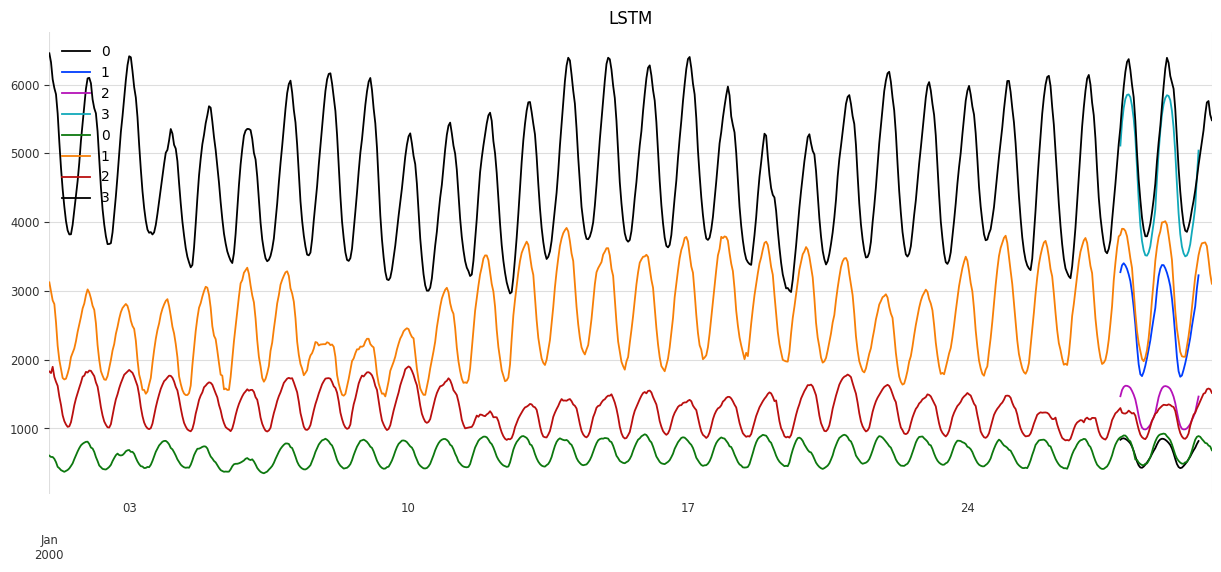

In [64]:
# Plot the predictions

plt.figure(figsize=(15, 6))
predictions_df.iloc[:, :4].plot(label = 'Predictions',ax=plt.gca())
series_df.iloc[:, :4].plot(label = 'Actuals', ax=plt.gca())
plt.title("LSTM")
plt.legend()
plt.show()